$\LARGE{Least\ Squares\ Line\ fitting}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [5]:
#Least squares function
def LS_fitting(X, y):
    #The line model y = mx + b
    #Need to find m and b

    #Matrix X
    mat_X = np.column_stack([X, np.ones(len(X))])
    mat_Y = y

    #The matrix m and b 
    # The matrix B = (X^T * X)^-1 * X^T * Y
    B = np.linalg.inv(mat_X.T @ mat_X) @ mat_X.T @ mat_Y

    return B

In [10]:
#Testing on a dataset

#Parameters
true_w1 = 3.5
true_w2 = -2.0
true_b = 10.0

#Generate random X data 
num_samples = 100
#Creates a 100x2 matrix of random numbers between 0 and 10
X = np.random.rand(num_samples, 2) * 10 

#Calculate the pure y values
#x[:, 0] is for the first column i.e x1 similarly X[:, 1] is for second column i.e x2
y_pure = (true_w1 * X[:, 0]) + (true_w2 * X[:, 1]) + true_b

#Adding random noise
noise = np.random.normal(loc=0.0, scale=2.0, size=num_samples)
y_noisy = y_pure + noise

#Running the function
predicted_B = LS_fitting(X, y_noisy)

print(f"Predicted Parameters: {np.round(predicted_B, 2)}")

Predicted Parameters: [ 3.58 -2.19 10.72]


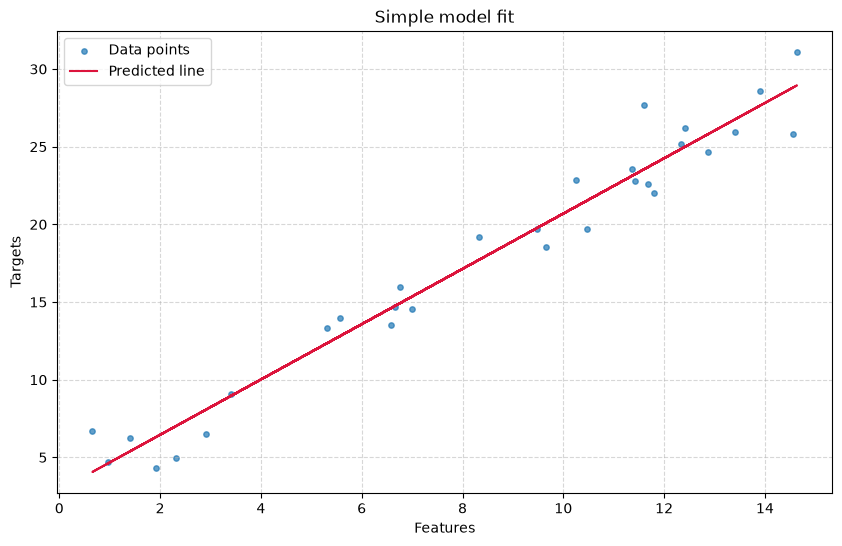

In [37]:
#Plotting a 1D X, y dataset
rng = np.random.default_rng(42)
X = rng.uniform(0, 15, size=(30, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 2, size=30)

#Prediction
predicted_B = LS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='crimson', label='Predicted line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Simple model fit')
plt.legend(loc='upper left')
plt.show()

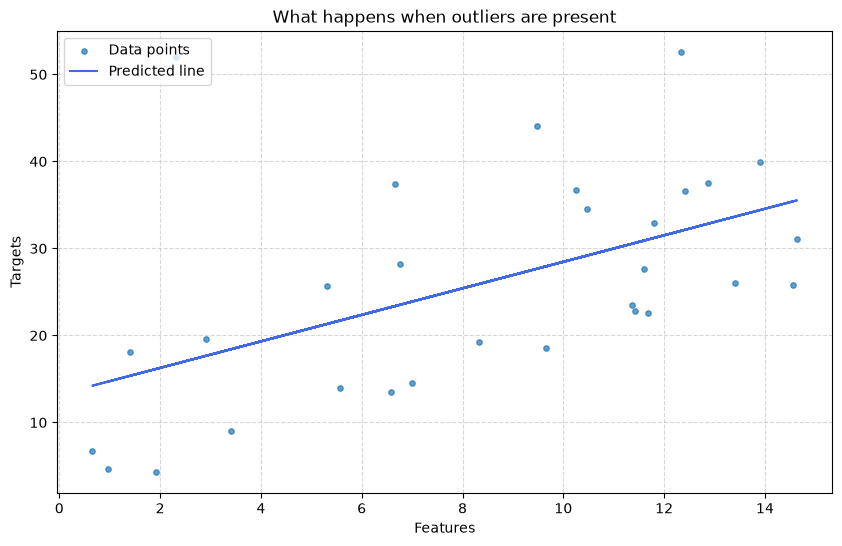

In [42]:
#What happens when the outliers are present
outlier_index = rng.choice(len(y), size = 5, replace = False)
y[outlier_index] += rng.uniform(10, 15, size=5)

#Prediction
predicted_B = LS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='royalblue', label='Predicted line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('What happens when outliers are present')
plt.legend(loc='upper left')
plt.show()

In [43]:
#Trying to fit for a vertical line
X_vertical = np.array([5.0, 5.0, 5.0, 5.0, 5.0])
y_vertical = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

try:
    predicted_B = LS_fitting(X_vertical, y_vertical)
    print(predicted_B)
except Exception as e:
    print(f"Can't  fit:\n{e}")

Can't  fit:
Singular matrix


$\LARGE{Total\ Least\ Squares\ Fitting}$

In [48]:
#Total least squares function
def TLS_fitting(X, y):

    #Taking the means
    X_bar = np.mean(X)
    y_bar = np.mean(y)

    #Centroid vector
    centroid = np.array([X_bar, y_bar])

    mat_U = np.column_stack([X - X_bar, y - y_bar])

    #Getting the eigne vectors of (U^T)(U)
    eig_vals, eig_vectors = np.linalg.eig(mat_U.T @ mat_U)

    #Getting the minimum eigen value
    min_eig_val_idx = np.argmin(eig_vals)

    #Getting the eigenvector corresponds to the minimum eigenvalue
    min_eig_vector = eig_vectors[:,min_eig_val_idx]

    #The constant value
    d = np.dot(min_eig_vector, centroid)

    #Parameters vector
    parameters = np.append(min_eig_vector, d)

    return parameters

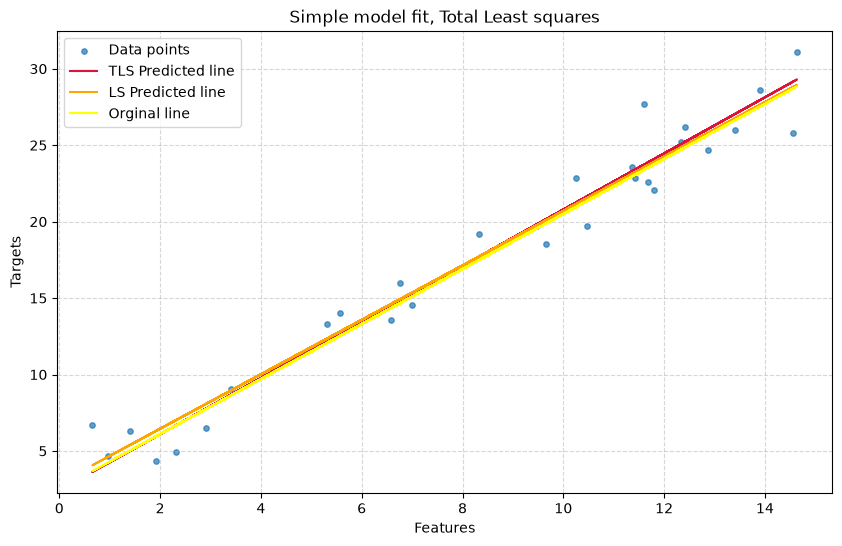

In [56]:
#Using the same above data set
#Plotting a 1D X, y dataset
rng = np.random.default_rng(42)
X = rng.uniform(0, 15, size=(30, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 2, size=30)

#Prediction
predicted_B = LS_fitting(X, y)
parameters = TLS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, (- X*parameters[0] + parameters[2])/(parameters[1]), color='crimson', label='TLS Predicted line')
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='orange', label='LS Predicted line')
plt.plot(X, 2.5 + 1.8*X, color='yellow', label='Orginal line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Simple model fit, Total Least squares')
plt.legend(loc='upper left')
plt.show()

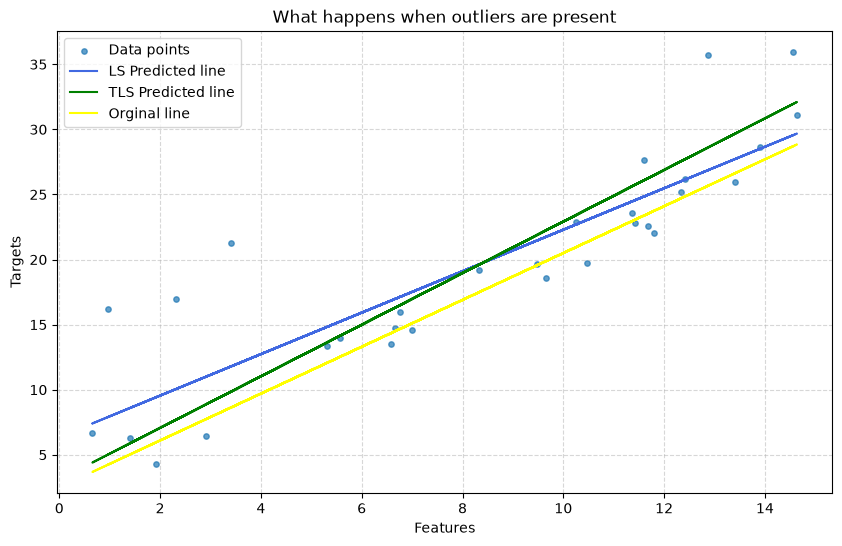

In [55]:
#The effect of outliers
outlier_index = rng.choice(len(y), size = 5, replace = False)
y[outlier_index] += rng.uniform(10, 15, size=5)

#Prediction
predicted_B = LS_fitting(X, y)
parameters = TLS_fitting(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X, X*predicted_B[0] + predicted_B[1], color='royalblue', label='LS Predicted line')
plt.plot(X, (- X*parameters[0] + parameters[2])/(parameters[1]), color='green', label='TLS Predicted line')
plt.plot(X, 2.5 + 1.8*X, color='yellow', label='Orginal line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('What happens when outliers are present')
plt.legend(loc='upper left')
plt.show()

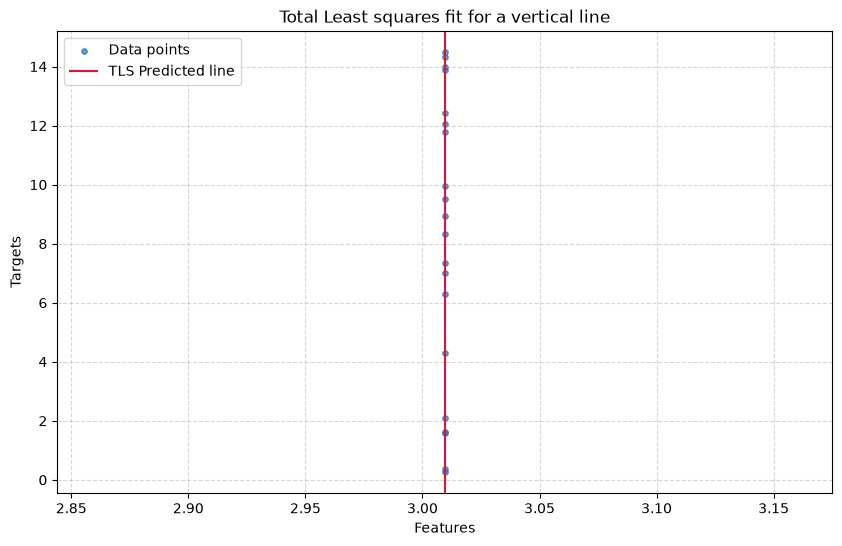

In [ ]:
#The advantage here is this can fit into vertical lines as well
#Trying to fit for a vertical line
x_value = rng.uniform(0, 10)
X_vertical = np.full((20, 1), x_value)
y_vertical = rng.uniform(0, 15, size=(20, 1))

try:
    parameters = TLS_fitting(X_vertical, y_vertical)
    plt.figure(figsize=(10, 6))
    plt.scatter(X_vertical, y_vertical, label='Data points', alpha=0.7, s=15)

    #TLS represents the line as a*x + b*y = d.
    #For a vertical line, b is approximately zero, so x = d/a.
    vertical_x = parameters[2] / parameters[0]
    plt.axvline(vertical_x, color='crimson', label='TLS Predicted line')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlabel('Features')
    plt.ylabel('Targets')
    plt.title('Total Least squares fit for a vertical line')
    plt.legend(loc='upper left')
    plt.show()

except Exception as e:
    print(f"Can't fit:\n{e}")

In [75]:
#TLS with robust estimator
from scipy.optimize import minimize

def robust_TLS_fittin(X, y, sigma):
    #Taking the means
    X_bar = np.mean(X)
    y_bar = np.mean(y)

    #Centroid vector
    centroid = np.array([X_bar, y_bar])

    mat_U = np.column_stack([X - X_bar, y - y_bar])

    #Getting the eigne vectors of (U^T)(U)
    eig_vals, eig_vectors = np.linalg.eig(mat_U.T @ mat_U)

    #Getting the minimum eigen value
    min_eig_val_idx = np.argmin(eig_vals)

    #Getting the eigenvector corresponds to the minimum eigenvalue
    min_eig_vector = eig_vectors[:,min_eig_val_idx]

    #The constant value
    d = np.dot(min_eig_vector, centroid)

    #Parameters vector
    initial_guess = np.append(min_eig_vector, d)

    def robust_objective(params):
        a, b, d = params
        
        norm = np.sqrt(a**2 + b**2)
        u = (a * X + b * y - d) / norm
        
        robust_losses = (u**2) / (sigma**2 + u**2)
        
        return np.sum(robust_losses)

    result = minimize(robust_objective, initial_guess)
    
    # Extract the final optimized parameters
    final_a, final_b, final_d = result.x
    
    # Re-normalize just to guarantee a^2 + b^2 = 1 perfectly for the final output
    final_norm = np.sqrt(final_a**2 + final_b**2)
    parameters = np.array([final_a / final_norm, final_b / final_norm, final_d / final_norm])

    return parameters


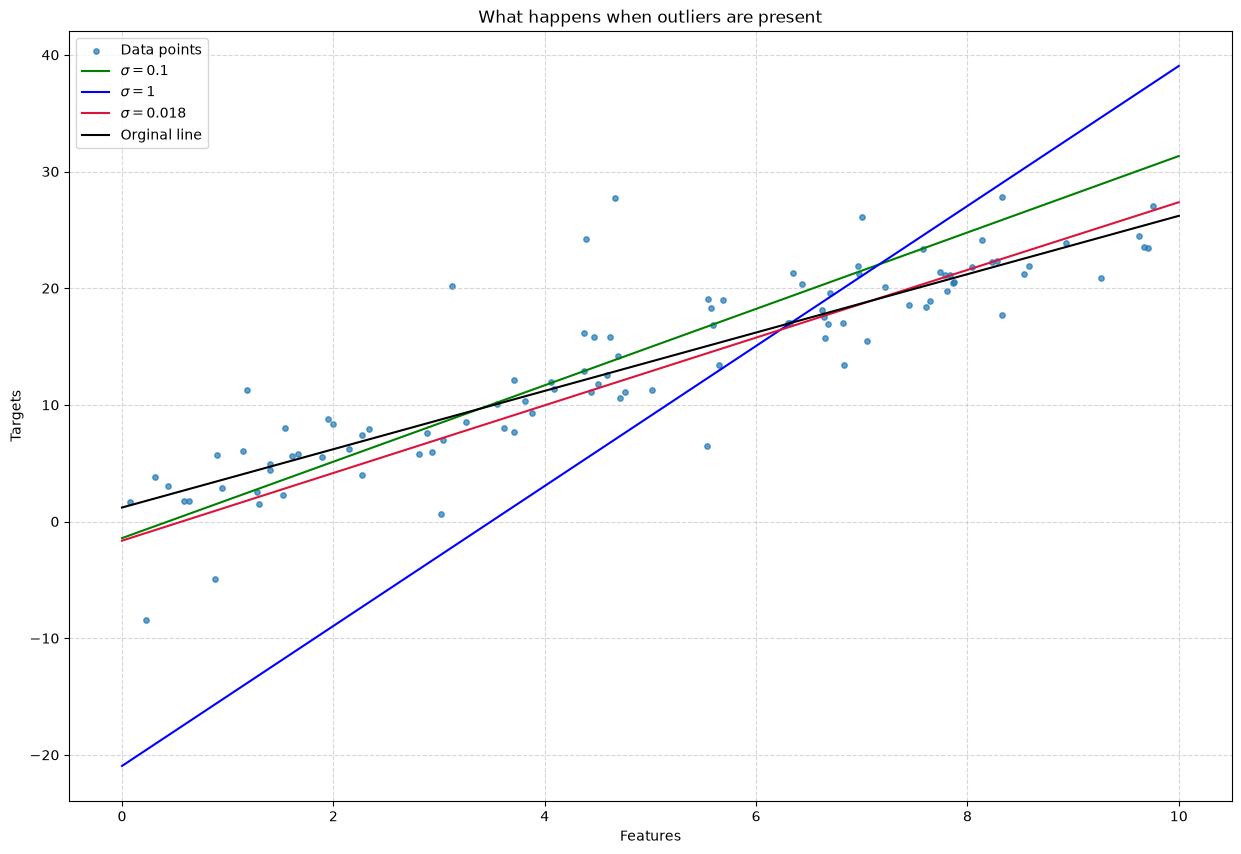

In [102]:
#Testing with a dataset with outliers with different sigma values
rng = np.random.default_rng(42)
X_new = rng.uniform(0, 10, size=(100, 1))
y_new = 1.2 + 2.5 * X_new[:, 0] + rng.normal(0, 2, size=100)
#Adding outliers
outlier_idx = rng.choice(len(y_new), size=15, replace=False)
y_new[outlier_idx] += rng.uniform(-10, 15, size=15)

#fitting
parameters_1 = robust_TLS_fittin(X_new, y_new, 0.1)
parameters_2 = robust_TLS_fittin(X_new, y_new, 1)
parameters_3 = robust_TLS_fittin(X_new, y_new, 0.018)

#Just to plot
X_plot = np.linspace(0, 10, 100)

plt.figure(figsize=(15, 10))
plt.scatter(X_new, y_new, label = 'Data points', alpha = 0.7, s = 15)
plt.plot(X_plot, (- X_plot*parameters_1[0] + parameters_1[2])/(parameters_1[1]), color='green', label='$\sigma = 0.1$')
plt.plot(X_plot, (- X_plot*parameters_2[0] + parameters_2[2])/(parameters_2[1]), color='blue', label='$\sigma = 1$')
plt.plot(X_plot, (- X_plot*parameters_3[0] + parameters_3[2])/(parameters_3[1]), color='crimson', label='$\sigma = 0.018$')
plt.plot(X_plot, 1.2 + 2.5*X_plot, color='black', label='Orginal line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('What happens when outliers are present')
plt.legend(loc='upper left')
plt.show()


$\LARGE RANSAC$

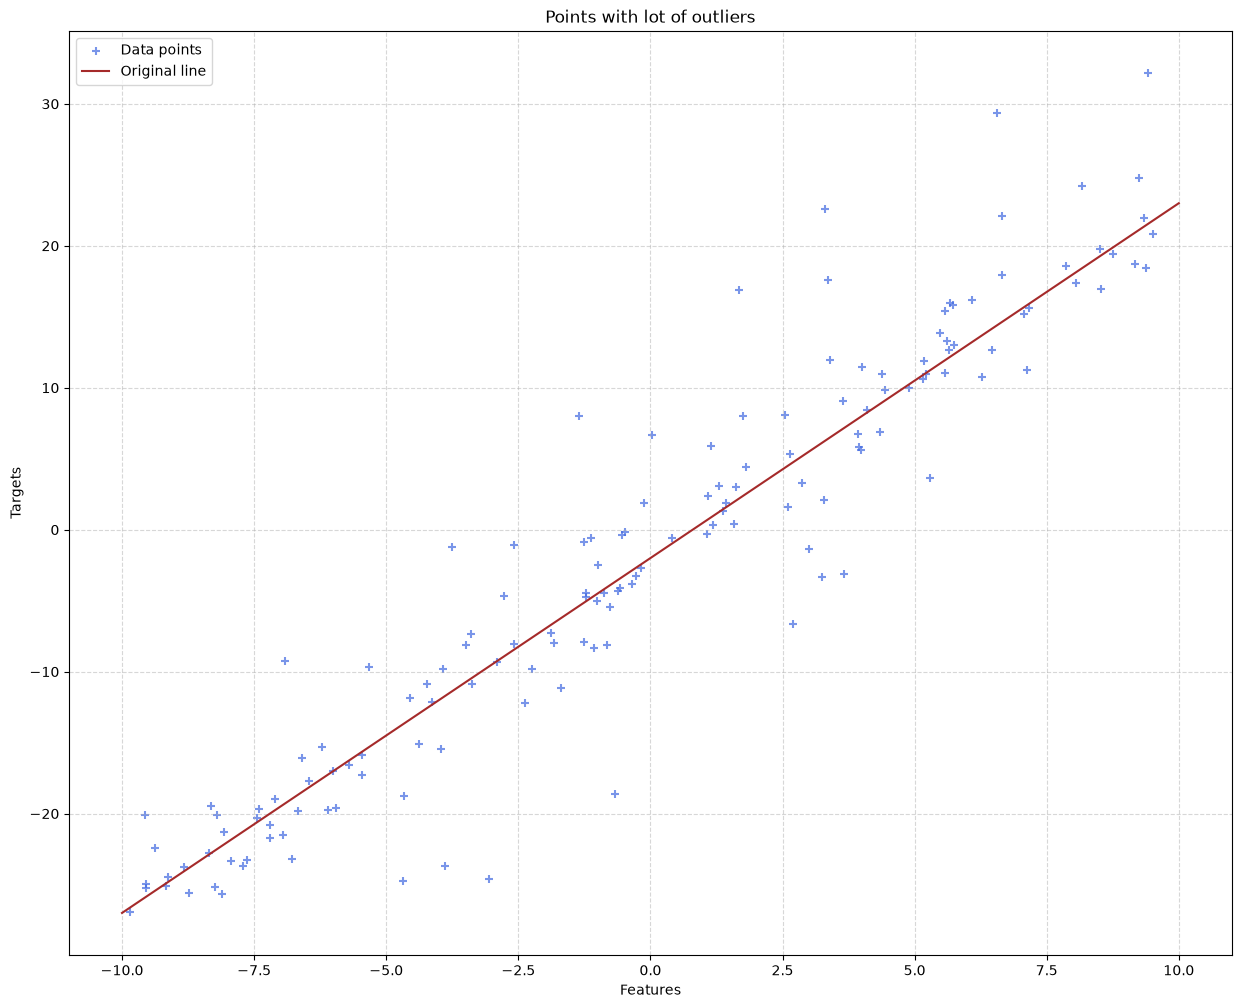

In [127]:
#Using a data set with a large number of outliers
rng = np.random.default_rng(42)
X = rng.uniform(-10, 10, size=(150, 1))
y = -2 + 2.5 * X[:, 0] + rng.normal(0, 2, size=150)
#Adding outliers
outlier_idx = rng.choice(len(y), size=40, replace=False)
y[outlier_idx] += rng.uniform(-15, 15, size=40)

X_plot = np.linspace(-10, 10, 100)

plt.figure(figsize=(15, 12))
plt.scatter(X, y, color='royalblue', marker='+', label = 'Data points', alpha = 0.7, s = 40)
plt.plot(X_plot, -2 + 2.5*X_plot, color = 'brown', label='Original line')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Points with lot of outliers')
plt.show()


(np.float64(-0.9142759060651678), np.float64(0.4050920482911463), np.float64(0.5928986859264457))


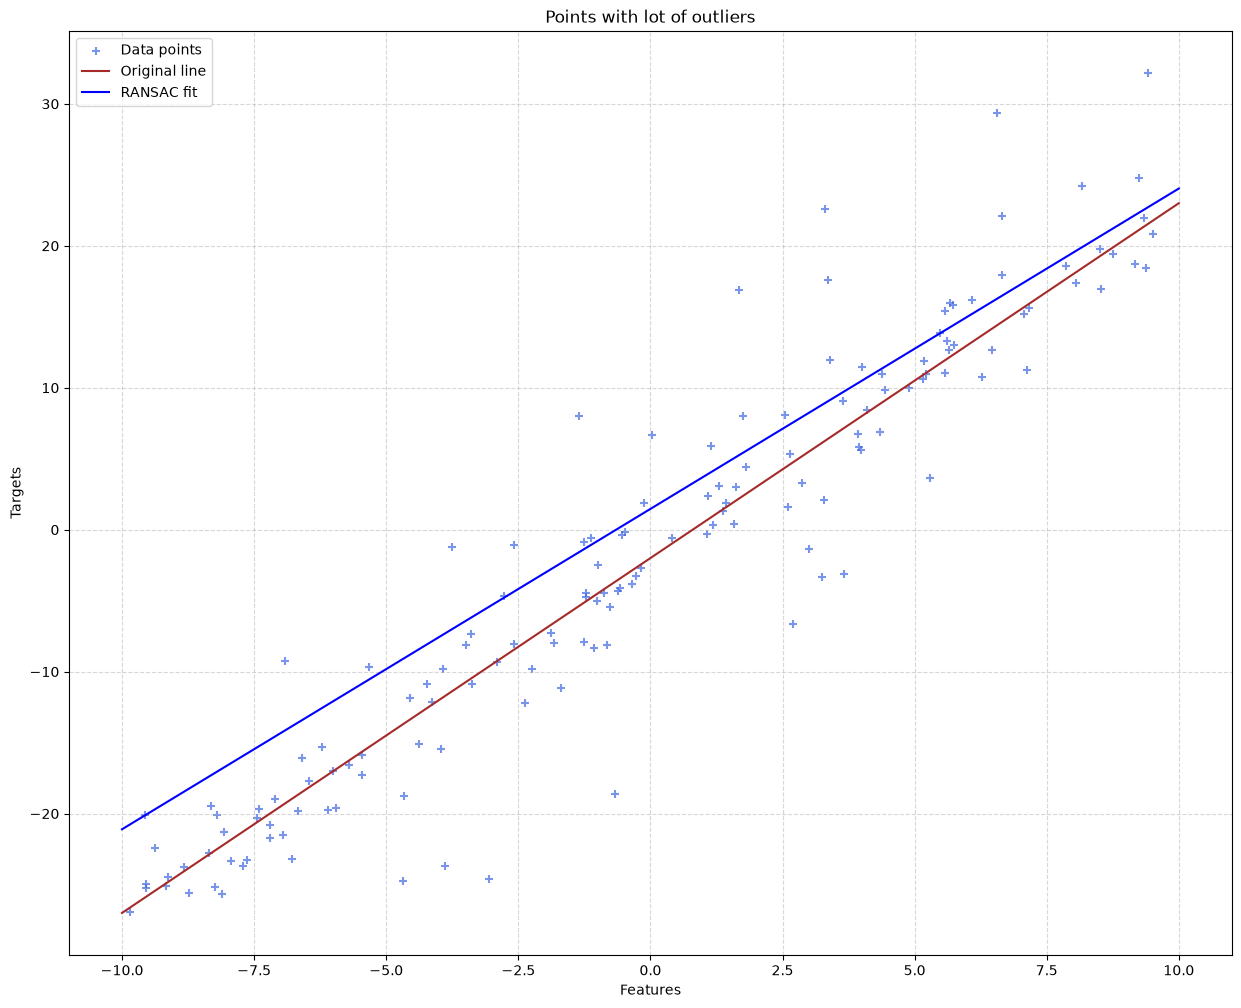

In [159]:
#RANSAC function
def RANSAC_fitting(X, y):

    #Taking the means
    X_bar = np.mean(X)
    y_bar = np.mean(y)

    #Taking standard deviation
    X_sigma = np.std(X)
    y_sigma = np.std(y)

    #Centroid vector
    centroid = np.array([X_bar, y_bar])

    def line(p1, p2):
        #To prevent zerodivisionerror
        if p1[0] == p2[0]:
            p2 = (p2[0] + 1e-5, p2[1])

        #Gradient
        m = (p2[1]- p1[1])/(p2[0] - p1[0])

        #intercept 
        intercept = p2[1] - np.dot(m, p2[0])

        #now y = m.x + b
        #Turning into ax + by  = d
        norm = (1**2 + np.abs(m)**2)**0.5
        a, b, d = -m/norm, 1/norm, intercept/norm

        return a, b, d

    #Declaring variables to store the final value
    parameters_set = None
    max_number_of_inliers = 0

    #Choosing the number of iterations
    N = 100

    #Iterating to choose the best line
    for i in range(N):

        #Selecting the points randomly
        p1 = (X[i, 0], y[i])
        p2 = (X[len(y) - i - 1, 0], y[len(y) - i - 1])
        '''idx1, idx2 = np.random.choice(len(X), 2, replace=False)
        p1 = (X[idx1], y[idx1])
        p2 = (X[idx2], y[idx2])'''

        #Calling the function and getting the paramers
        parameters = line(p1, p2)

        #Getting the residual vector
        residuals = (parameters[0] * X) + (parameters[1] * y) - parameters[2]

        #Setting the threshold
        threshold = ((X_sigma**2 + y_sigma**2)**0.5)*2

        #Counting the outliers
        neglicting_res_idx = np.abs(residuals) < threshold

        #Number of inliers
        number_of_inliers = np.sum(neglicting_res_idx)

        #Choosing the max
        if number_of_inliers > max_number_of_inliers:
            max_number_of_inliers = number_of_inliers
            parameters_set = parameters


    return parameters_set
    
parameters = RANSAC_fitting(X, y)
print(parameters)
plt.figure(figsize=(15, 12))
plt.scatter(X, y, color='royalblue', marker='+', label = 'Data points', alpha = 0.7, s = 40)
plt.plot(X_plot, -2 + 2.5*X_plot, color = 'brown', label='Original line')
plt.plot(X_plot, (- X_plot*parameters[0] + parameters[2])/(parameters[1]), color='blue', label='RANSAC fit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Points with lot of outliers')
plt.show()


        

    